In [2]:
import re
import glob
import subprocess

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import gaussian_kde

matplotlib.rcParams["svg.fonttype"] = "none"

In [14]:
# enable R coding
%load_ext rpy2.ipython

# LD plots

In [69]:
base_dir = '/path/to/input/'
out_dir = '/path/to/oupput/'

plink_vcor = base_dir+"giggles-genotyping_final-vcf.unphased_simple_var_ids.and.gatk_smvar_calls.chr{0}.vcor"
plink_pvar      = base_dir+"giggles-genotyping_final-vcf.unphased_simple_var_ids.pvar"
top_r2  = out_dir+"sv_best_r2.tsv"

r2_threshold  = 0.5
min_maf    = 0.01     

sv_classes = ["DEL", "DUP", "INV", "INS", "COMPLEX"]
colors = {"DEL": "#3B6DB3", "INS": "#1B2A5E", "COMPLEX": "#4FB0E3"}

size_bins   = [0, 100, 500, 1000, 5000, np.inf]
size_labels = ["<100", "100-500", "500-1k", "1k-5k", ">5k"]

size_colors = {"<100":"#F4C20D","100-500":"#F39C1F","500-1k":"#E8701A","1k-5k":"#D13B27",">5k":"#8E1B1B"}


In [59]:
#for each SV, get SV size, class and maf

rows = []
with open(plink_pvar) as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        cols = line.rstrip("\n").split("\t")
        sv_id = cols[2]
        info  = cols[6] if len(cols) > 6 else ""
        cls   = sv_id.split('-')[2]
        sv_size = sv_id.split('-')[3]
        sv_maf = info.split('MAF=')[1].split(';')[0]
        rows.append({"sv_id": sv_id, "class": cls,
                         "size": sv_size, "maf": sv_maf})
            
meta = pd.DataFrame(rows)

In [ ]:
#for each SV, record best r2 with an SNV

def is_sv(id_str):
    if pd.isna(id_str) or id_str == ".":
        return False
    return any("-{}-".format(c) in id_str for c in sv_classes)

chunks = []
for chrom in range(1,23):
    f = plink_vcor.format(chrom)
    cmd = "awk 'NR>1 && ($3!=\".\" || $6!=\".\")' {}".format(f)
    proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE)
    chunks.append(pd.read_csv(
        proc.stdout, sep="\t",
        names=["chrom_A", "pos_A", "id_A", "chrom_B", "pos_B", "id_B", "r2"],
        dtype={"id_A": str, "id_B": str, "r2": float},
    ))
    proc.wait()
ld = pd.concat(chunks, ignore_index=True)
print("SV-containing pairs: {:,}".format(len(ld)))

# keep pairs with 1 SV
ld["sv_A"] = ld["id_A"].apply(is_sv)
ld["sv_B"] = ld["id_B"].apply(is_sv)
sv_snv = ld[ld["sv_A"] ^ ld["sv_B"]].copy()
sv_snv["sv_id"] = np.where(sv_snv["sv_A"], sv_snv["id_A"], sv_snv["id_B"])


In [60]:
best = (sv_snv.groupby("sv_id", as_index=False)["r2"].max()
        .rename(columns={"r2": "best_r2"})
        .merge(meta, on="sv_id", how="inner"))
best.to_csv(top_r2, sep="\t", index=False)
print("Number of SVs:{0}".format(len(best)))

Number of SVs:151290


In [62]:
best["size"] = pd.to_numeric(best["size"], errors="coerce")
best["size_bin"] = pd.cut(best["size"], bins=size_bins, labels=size_labels, right=False)

best["maf"] = pd.to_numeric(best["maf"], errors="coerce")
common = best[best["maf"] >= min_maf].copy()      
present = [c for c in sv_classes if c in common["class"].values]

print("common SVs (MAF >= {:.0%}): {:,}".format(min_maf, len(common)))
print(common["class"].value_counts())

common SVs (MAF >= 1%): 55,714
INS        24993
DEL        19565
COMPLEX    11156
Name: class, dtype: int64


## SVs with tag SNV

Plot percent of common SVs (MAF >= 0.01) by class with r2 >= 0.5 to an SNV 

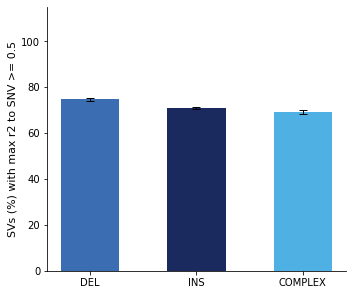

In [63]:
def taggability_table(df, group_col, order):
    g  = df.groupby(group_col)["best_r2"]
    n  = g.size()
    p  = g.apply(lambda s: (s >= r2_threshold).mean())
    ci = 1.96 * np.sqrt(p * (1 - p) / n)
    out = pd.DataFrame({"pct": p * 100, "n": n, "ci": ci * 100})
    return out.loc[[g for g in order if g in out.index]].reset_index()

tag_cls = taggability_table(common, "class", present)

fig, ax = plt.subplots(figsize=(5, 4.2))
bars = ax.bar(tag_cls["class"], tag_cls["pct"],
              color=[colors.get(c, "#888") for c in tag_cls["class"]],
              yerr=tag_cls["ci"], capsize=4, width=0.55, zorder=3,
              error_kw={"elinewidth": 1, "ecolor": "black", "capthick": 1})

ax.set_ylim(0, 115)
ax.set_ylabel("SVs (%) with max r2 to SNV >= 0.5", fontsize=11)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## Max r2 with SNV by SV size

Plot for each SV size class, maximum r2 with SNV for common SVs (MAF >= 0.01)

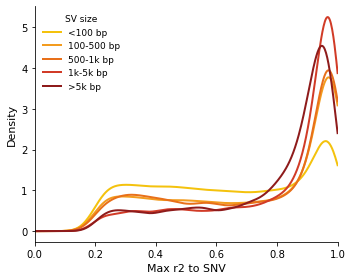

In [68]:
x_grid = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(5, 4))
for sbin in size_labels:
    vals = common.loc[common["size_bin"].astype(str) == sbin,
                      "best_r2"].dropna().values
    if len(vals) < 5:
        continue
    dens = gaussian_kde(vals, bw_method=0.15)(x_grid)
    ax.plot(x_grid, dens, color=size_colors[sbin], lw=2,
            label="{} bp".format(sbin))

ax.set_xlim(0, 1)
ax.set_xlabel("Max r2 to SNV", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(frameon=False, fontsize=9, title="SV size", title_fontsize=9)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()